# One tracking frame

Run on `hhw9l84` with `~/.virtualenvs/rfmapping`. Run all once; rerun the last plotting cell for a new random frame.

**Accepted coordinate convention:** corrected HD = 0 is screen RF = 0. RF spans −180° to 180°. RF is positive clockwise; corrected HD is positive counterclockwise, exactly as in minimal GLM / MATLAB.

The VS inputs, camera clock, HD correction, tracking XY, eye correction and `bearing()` below are copied from `minimal_glm.ipynb`. HD and eye handling match this repository's `matlab.ipynb`; its saved `hd_trials_times.npy` is already corrected and sampled at trial onsets. This plot uses an actual tracking frame.

For display, the screen center is (0, 0) and RF 0° is +X. XY is rotated into that common frame once; corrected HD is drawn directly. The VS arc is drawn from MAT X/width; bearing rays are drawn from separately computed bearing angles and circle intersection, without using VS endpoints.

Triangle = animal; arrow = corrected HD; thick arc = VS extent; two dashed rays = bearing extent. VS luminance is ignored; Y (elevation) is printed. XY uses Motive length units. Both panels have an opaque white background and share a legend outside the axes.

The right panel is an ego view of the same frame: eye at (0, 0), HD pointing up, +X to the animal's right and +Y forward. It only translates and rotates the existing geometry; the screen circle moves with respect to the eye. Both panels use the same scale.


In [34]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import pandas as pd
from scipy.io import loadmat

date = "260827"
session_id = 5
headplate = "hp4"
camera_channel = 1
camera_threshold = 11000
session_dir = Path(f"/mnt/senzailab/Kai/#Recording/m19/{date}/{date}_{session_id}")
data_dir = session_dir / "data"

calibration = json.loads((session_dir / f"{date}.calib").read_text())
screen_center_xy = np.asarray(calibration["screen_bottom_center"][:2])
screen_radius = calibration["screen_diamter"] / 2
screen_zero_deg = calibration["screen_center"]


In [35]:
# VS input lines copied from minimal_glm; retain Y for the printed value.
trials = pd.DataFrame(loadmat(session_dir / f"{date}.mat", simplify_cells=True)["trials"])
trial_edges = np.load(data_dir / "on_list_times.npy")
trial_start = trial_edges[:-1]
stimulus_center = trials["Square_PositionX"].to_numpy()
stimulus_width = trials["Square_Size"].to_numpy()
stimulus_y = trials["Square_PositionY"].to_numpy()


In [36]:
# Copied from minimal_glm: same camera clock as matlab.ipynb.
session_info = json.loads((data_dir / "session_info.json").read_text())["session_info"]
adc_folder = (Path(session_info["base_path"]) / session_info["record_nodes"]
              / session_info["experiment_id"] / session_info["recording_name"]
              / "continuous" / session_info["continuous_ADC_folder"])
adc_time = np.load(adc_folder / "timestamps.npy", mmap_mode="r")
camera = np.memmap(adc_folder / "continuous.dat", dtype=np.int16, mode="r")[
    camera_channel::session_info["ADC_input_channel"]
]
low = np.r_[False, camera < camera_threshold, False]
low_start = np.flatnonzero(~low[:-1] & low[1:])
low_end = np.flatnonzero(low[:-1] & ~low[1:])
complete = (low_start > 0) & (low_end < len(camera))
frame_time = (adc_time[low_start[complete]] + adc_time[low_end[complete]]) / 2
del adc_time, camera, low


In [37]:
# Copied from minimal_glm: raw JSON HD, then correct once as in matlab.ipynb.
hd_data = json.loads((data_dir / "processed/head_direction.json").read_text())[headplate]
frame_hd = np.asarray(hd_data["head_direction_deg"])[:len(frame_time)]
frame_hd = (frame_hd - calibration["screen_center"]) % 360


In [38]:
# Copied from minimal_glm: tracking XY is read independently.
motive = pd.read_csv(session_dir / f"{date}.csv", header=[2, 3, 6, 7], skip_blank_lines=False)
frame_xy = motive["Rigid Body"][headplate]["Position"][["X", "Y"]].to_numpy()[:len(frame_time)]


In [39]:
# Copied from minimal_glm / matlab.ipynb: the same planar eye correction.
theta = np.radians(frame_hd)
offset_x, offset_y = calibration["hp_to_eye_center"][:2]
frame_eye_xy = frame_xy + np.column_stack([
    offset_x * np.cos(theta) - offset_y * np.sin(theta),
    offset_x * np.sin(theta) + offset_y * np.cos(theta),
]) - calibration["screen_bottom_center"][:2]


In [40]:
# bearing() is copied verbatim from minimal_glm, which matches RFmapping_core_fm.m.
def bearing(stimulus_deg, eye_xy, hd_deg):
    # RF stimulus angles run opposite to world XY / Motive HD.
    theta = np.radians(screen_zero_deg - stimulus_deg)
    ray_x = screen_radius * np.cos(theta) - eye_xy[:, 0]
    ray_y = screen_radius * np.sin(theta) - eye_xy[:, 1]
    world_bearing = np.degrees(np.arctan2(ray_y, ray_x))
    return (hd_deg + screen_zero_deg - world_bearing + 180) % 360 - 180

frame_trial = np.searchsorted(trial_edges, frame_time, side="right") - 1
valid_rows = np.flatnonzero(
    (frame_trial >= 0) & (frame_trial < len(trials))
    & np.isfinite(frame_hd) & np.isfinite(frame_eye_xy).all(axis=1)
)
source_trials = frame_trial[valid_rows]
left_deg = bearing(stimulus_center[source_trials] - stimulus_width[source_trials] / 2,
                   frame_eye_xy[valid_rows], frame_hd[valid_rows])
right_deg = bearing(stimulus_center[source_trials] + stimulus_width[source_trials] / 2,
                    frame_eye_xy[valid_rows], frame_hd[valid_rows])
all_bearing_edges_deg = np.column_stack([left_deg, right_deg])
all_bearing_width_deg = (right_deg - left_deg) % 360


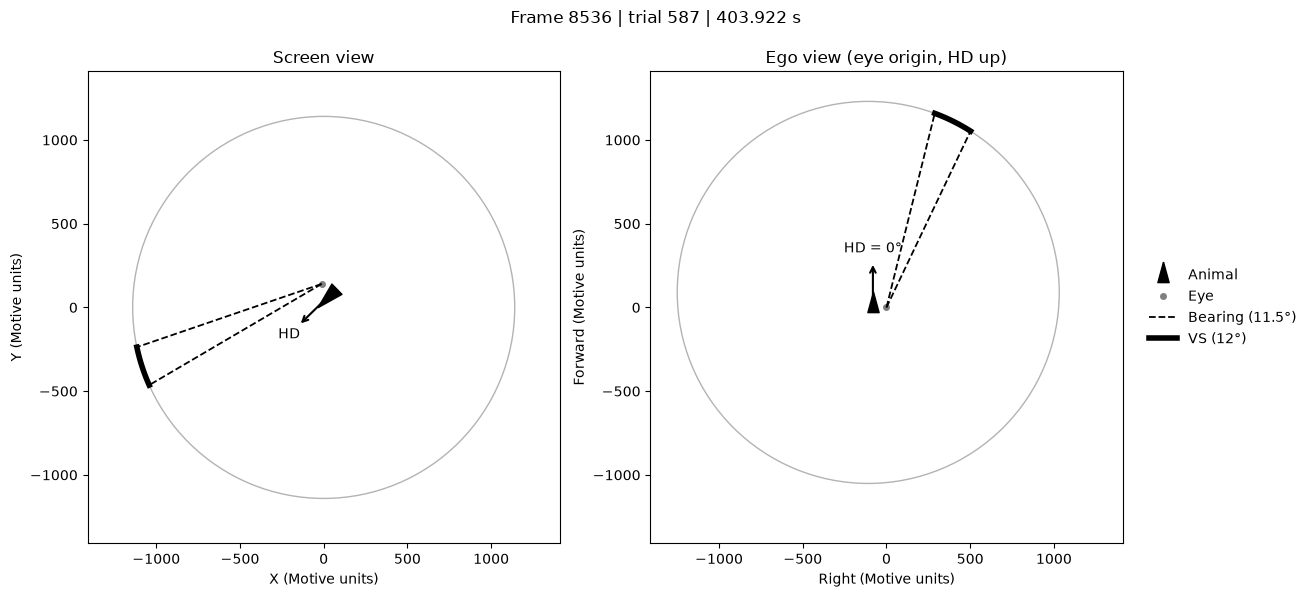

Animal XY (tracking CSV): [ 67.413513 106.693359]
HD (corrected, as in matlab.ipynb): 224.37 deg
VS [X, Y]: [162 -15] deg; width: 12 deg
Bearing edges: [13.97 25.49] deg; width: 11.52 deg


In [52]:
# Rerun this cell for another random frame; all inputs were read/calculated above.
i = np.random.default_rng().integers(len(valid_rows))
row = valid_rows[i]
frame = row
trial = frame_trial[row]
hd_deg = frame_hd[row]  # Already corrected: HD zero = RF zero.
vs_position = np.array([stimulus_center[trial], stimulus_y[trial]])
vs_width_deg = stimulus_width[trial]
bearing_edges_deg = all_bearing_edges_deg[i]
bearing_width_deg = all_bearing_width_deg[i]

# Put every XY point in the same screen-zero frame; do not correct HD again.
zero = np.radians(screen_zero_deg)
world_to_plot = np.array([[np.cos(zero), -np.sin(zero)], [np.sin(zero), np.cos(zero)]])
animal_xy = (frame_xy[row] - screen_center_xy) @ world_to_plot
eye_xy = frame_eye_xy[row] @ world_to_plot
forward = np.array([np.cos(np.radians(hd_deg)), np.sin(np.radians(hd_deg))])
left = np.array([-forward[1], forward[0]])

# VS is drawn directly from its MAT angles, independently of HD and bearing.
vs_arc_angle = np.radians(-np.linspace(vs_position[0] - vs_width_deg / 2, vs_position[0] + vs_width_deg / 2, 60))
vs_arc_xy = screen_radius * np.column_stack([np.cos(vs_arc_angle), np.sin(vs_arc_angle)])

# Bearing rays: calculated angles -> directions -> circle intersection.
# No VS XY/endpoints or VS-derived ray lengths enter this calculation.
ray_angle = np.radians(hd_deg - bearing_edges_deg)
ray_direction = np.column_stack([np.cos(ray_angle), np.sin(ray_angle)])
projection = ray_direction @ eye_xy
ray_length = -projection + np.sqrt(projection**2 + screen_radius**2 - eye_xy @ eye_xy)
ray_end_xy = eye_xy + ray_length[:, None] * ray_direction

# Ego display only: eye at the origin, right on +X and HD/forward on +Y.
plot_to_ego = np.column_stack([-left, forward])
ego_animal_xy = (animal_xy - eye_xy) @ plot_to_ego
ego_screen_center = -eye_xy @ plot_to_ego
ego_vs_arc_xy = (vs_arc_xy - eye_xy) @ plot_to_ego
ego_ray_end_xy = (ray_end_xy - eye_xy) @ plot_to_ego
view_limit = 1.1 * (screen_radius + np.linalg.norm(eye_xy))

plt.style.use("default")
plt.rcParams.update({"savefig.facecolor": "white", "savefig.transparent": False})
fig, (ax, ego_ax) = plt.subplots(1, 2, figsize=(13, 6), layout="constrained", facecolor="white")
fig.suptitle(f"Frame {frame} | trial {trial} | {frame_time[row]:.3f} s")
ax.set_facecolor("white")
ax.add_patch(Circle((0, 0), screen_radius, fill=False, color="0.7"))
triangle = np.array([forward, -0.65 * forward + 0.45 * left, -0.65 * forward - 0.45 * left, forward])
ax.plot(*animal_xy, marker=triangle, markersize=18, color="black", linestyle="none", label="Animal")
ax.annotate("", xy=animal_xy + 0.22 * screen_radius * forward, xytext=animal_xy,
            arrowprops=dict(arrowstyle="->", color="black", linewidth=1.5))
ax.text(*(animal_xy + 0.29 * screen_radius * forward), "HD", ha="center", va="center")
ax.plot(*eye_xy, "o", color="0.5", markersize=4, label="Eye")
for j, end in enumerate(ray_end_xy):
    ax.plot([eye_xy[0], end[0]], [eye_xy[1], end[1]], "k--", linewidth=1.3,
            label=f"Bearing ({bearing_width_deg:.1f}°)" if j == 0 else None)
ax.plot(vs_arc_xy[:, 0], vs_arc_xy[:, 1], "k-", linewidth=4, label=f"VS ({vs_width_deg:g}°)")
ax.set(xlim=(-view_limit, view_limit), ylim=(-view_limit, view_limit),
       xlabel="X (Motive units)", ylabel="Y (Motive units)", aspect="equal",
       title="Screen view")

ego_ax.set_facecolor("white")
ego_ax.add_patch(Circle(ego_screen_center, screen_radius, fill=False, color="0.7"))
ego_ax.plot(*ego_animal_xy, marker=triangle @ plot_to_ego, markersize=18,
            color="black", linestyle="none", label="Animal")
ego_ax.annotate("", xy=ego_animal_xy + np.array([0, 0.22 * screen_radius]), xytext=ego_animal_xy,
                arrowprops=dict(arrowstyle="->", color="black", linewidth=1.5))
ego_ax.text(*(ego_animal_xy + np.array([0, 0.29 * screen_radius])), "HD = 0°", ha="center", va="center")
ego_ax.plot(0, 0, "o", color="0.5", markersize=4, label="Eye")
for j, end in enumerate(ego_ray_end_xy):
    ego_ax.plot([0, end[0]], [0, end[1]], "k--", linewidth=1.3,
                label=f"Bearing ({bearing_width_deg:.1f}°)" if j == 0 else None)
ego_ax.plot(ego_vs_arc_xy[:, 0], ego_vs_arc_xy[:, 1], "k-", linewidth=4, label=f"VS ({vs_width_deg:g}°)")
ego_ax.set(xlim=(-view_limit, view_limit), ylim=(-view_limit, view_limit),
           xlabel="Right (Motive units)", ylabel="Forward (Motive units)", aspect="equal",
           title="Ego view (eye origin, HD up)")
ego_ax.legend(loc="center left", bbox_to_anchor=(1.03, 0.5), frameon=False)
plt.show()

print("Animal XY (tracking CSV):", frame_xy[frame])
print(f"HD (corrected, as in matlab.ipynb): {hd_deg:.2f} deg")
print("VS [X, Y]:", vs_position, f"deg; width: {vs_width_deg:g} deg")
print(f"Bearing edges: {bearing_edges_deg.round(2)} deg; width: {bearing_width_deg:.2f} deg")
